In [49]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import scipy.interpolate as interpolate

# Funzione gaussiana
def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Apri il file ROOT
file = uproot.open("/home/riccardo-speziali/after_waveforms_analysis/sampic_mcp_setup_run209_final.root")
tree = file["picoTree"]

# Converti in Awkward Array
data = tree.arrays(library="ak")

# Estrai branch rilevanti
Cell0TimeStamp_PICOSEC = data["Cell0TimeStamp_PICOSEC"]  # array di array
Cell0TimeStamp_MCP    = data["Cell0TimeStamp_corr_MCP"]       # array piatto
cfd_PICO              = data["pulses_time_cfd30"]       # array di array
cfd_MCP               = data["mcp_time_cfd30"]          # array piatto
hits                  = data["hitxevent"]             # numero di hit per evento
channel               = data["Channel_PICOSEC"]         # canale PICOSEC
srs                   = data["TriggerIDSRS_MCP"]      # Trigger ID SRS
amplitude_PICOSEC     = data["pulses_amplitude"]     # array di array
e_peak_PICOSEC        = data["pulses_integral"]        # array di array
#track_chi_2          = data["track_chi_2"]             # chi2 del track




num_channel = 3

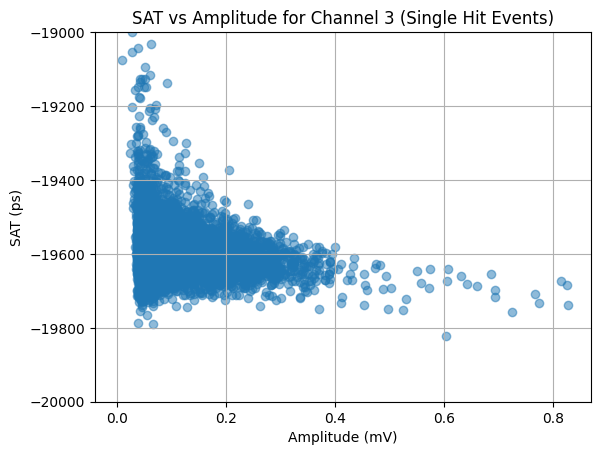

0.8282413482666016


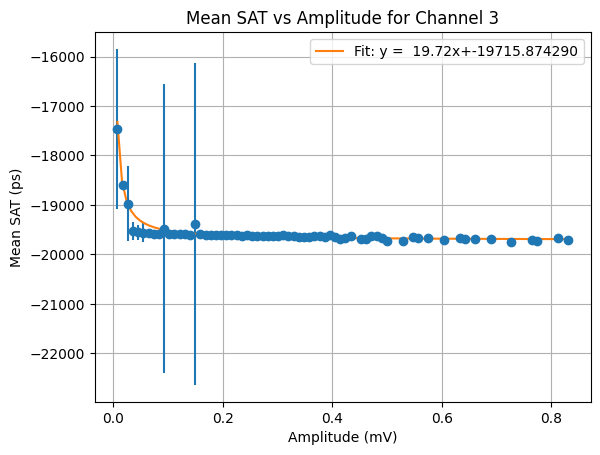

In [50]:
channel_mask = channel[:, 0] == num_channel
single_hit_mask = hits == 1

valid_mask = (
    (ak.num(amplitude_PICOSEC) >= 1) &
    (ak.num(cfd_PICO) >= 1) 
    
)

event_mask = channel_mask & single_hit_mask & valid_mask

good_amplitude = amplitude_PICOSEC[event_mask][:,0]





good_SAT = (cfd_PICO[event_mask][:,0] - cfd_MCP[event_mask] - (Cell0TimeStamp_MCP[event_mask]*1e3-Cell0TimeStamp_PICOSEC[event_mask][:,0]*1e3))





plt.scatter(good_amplitude, good_SAT, alpha=0.5)
plt.xlabel('Amplitude (mV)')
plt.ylabel('SAT (ps)')
plt.title(f'SAT vs Amplitude for Channel {num_channel} (Single Hit Events)')
plt.ylim(-20000,-19000)
plt.grid()
plt.show()



#altro plot dividere il grafico in bin e prendere la media per ogni bin
bins = np.linspace(ak.min(good_amplitude)-1, ak.max(good_amplitude)+1, 300)
bin_indices = np.digitize(good_amplitude, bins)
print(ak.max(good_amplitude))

bin_means = []
bin_std = []
bin_echarge_means = []
bin_echarge_std = []
for i in range(1, len(bins)):
    mask = bin_indices == i
    if ak.sum(mask) > 0:
        bin_means.append(ak.mean(good_SAT[mask]))
        bin_std.append(ak.std(good_SAT[mask]))
        bin_echarge_means.append(ak.mean(e_peak_PICOSEC[event_mask][:,0][mask]))
        bin_echarge_std.append(ak.std(e_peak_PICOSEC[event_mask][:,0][mask]))
    else:
        bin_means.append(np.nan)
        bin_std.append(np.nan)
        bin_echarge_means.append(np.nan)
        bin_echarge_std.append(np.nan)

bin_centers = 0.5 * (bins[:-1] + bins[1:])




# converti in NumPy
bin_means_np = ak.to_numpy(bin_means)
bin_std_np = ak.to_numpy(bin_std)
bin_centers_np = ak.to_numpy(bin_centers)

# filtro valori validi
mask = (~np.isnan(bin_means_np)) & (bin_centers_np > 0)
x = bin_centers_np[mask]
y = bin_means_np[mask]
err = bin_std_np[mask]

# fix valori critici
x = x + 1e-6                # evita log(0)
err = np.where(np.isnan(err) | (err == 0), 1e-6, err)

# funzione logaritmica
def func(x,b,c):
    return   + b/x +c

# fit pesato
#bounds = ([0, -np.inf,-np.inf], [2, np.inf,np.inf])

popt, pcov = curve_fit(func, x, y, sigma=err, absolute_sigma=True)
b, c= popt

# curva fittata
x_fit = np.linspace(min(x), max(x), 100)
y_fit = func(x_fit, b,c)

# plot
plt.errorbar(x, y, err, marker='o', linestyle='none')
plt.plot(x_fit, y_fit, label=f'Fit: y =  {b:.2f}x+{c:2f}')
plt.xlabel('Amplitude (mV)')
plt.ylabel('Mean SAT (ps)')
plt.title(f'Mean SAT vs Amplitude for Channel {num_channel}')
plt.grid()
plt.legend()
plt.show()

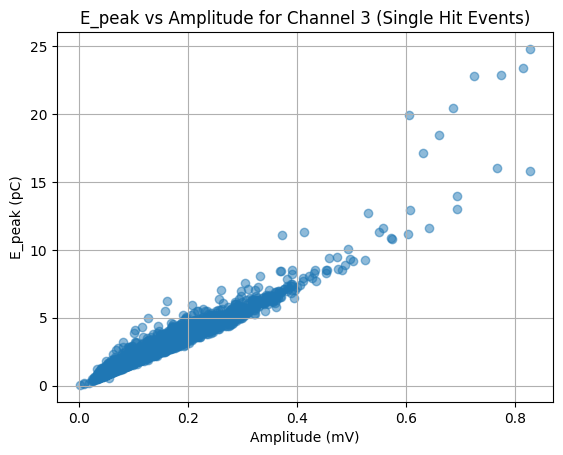

In [51]:
#amplitude vs e_peak
epeak_mask = ak.num(e_peak_PICOSEC) >= 1
valid_epeak_mask = event_mask & epeak_mask
good_epeak = e_peak_PICOSEC[valid_epeak_mask][:,0]

plt.scatter(good_amplitude, good_epeak, alpha=0.5)
plt.xlabel('Amplitude (mV)')
plt.ylabel('E_peak (pC)')
plt.title(f'E_peak vs Amplitude for Channel {num_channel} (Single Hit Events)')
plt.grid()
plt.show()



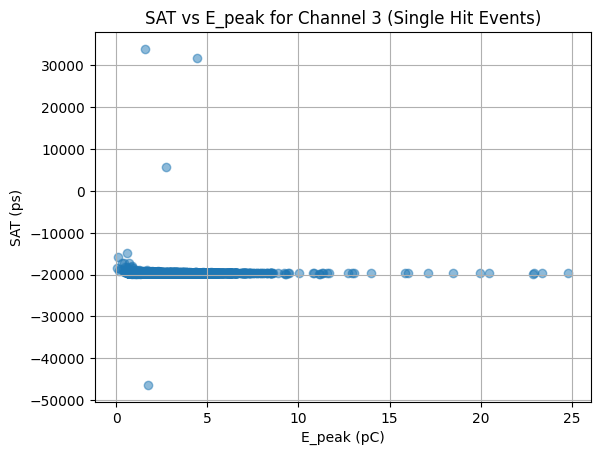

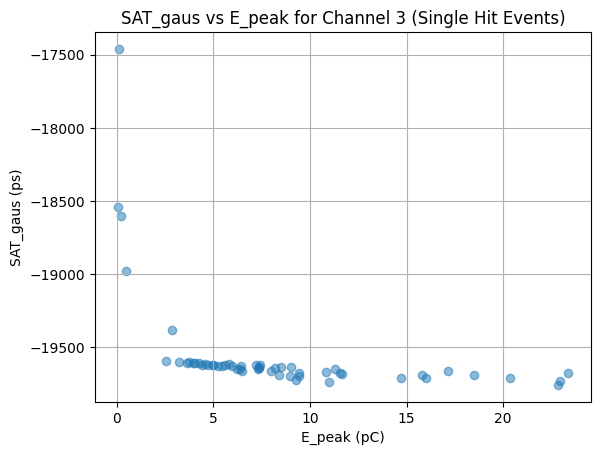

In [52]:
#sat vs charge
plt.scatter( good_epeak, good_SAT, alpha=0.5)
plt.xlabel('E_peak (pC)')
plt.ylabel('SAT (ps)')
plt.title(f'SAT vs E_peak for Channel {num_channel} (Single Hit Events)')
plt.grid()  
plt.show()


#sat_gaus vs charge


plt.scatter(bin_echarge_means, bin_means, alpha=0.5)
plt.xlabel('E_peak (pC)')
plt.ylabel('SAT_gaus (ps)')
plt.title(f'SAT_gaus vs E_peak for Channel {num_channel} (Single Hit Events)')
plt.grid()
plt.show()


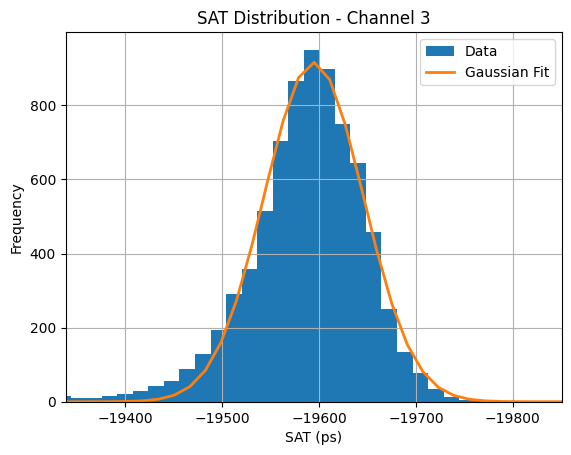

mu = -19594.44 ps, sigma = -51.20 ps


In [53]:
# pulizia dati
sat_values = ak.to_numpy(good_SAT)
sat_values = sat_values[~np.isnan(sat_values)]

mean = np.mean(sat_values)
std = np.std(sat_values)
#sat_values = sat_values[(sat_values > mean - 5*std) & (sat_values < mean + 5*std)]

# bin più ragionevoli
seg = 5000

# istogramma
hist, bin_edges = np.histogram(sat_values, bins=seg)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# fit gaussiano
popt, pcov = curve_fit(
    gauss,
    bin_centers,
    hist,
    p0=[max(hist), mean, std]
)

A_fit, mu_fit, sigma_fit = popt

# curva fit
x_fit = np.linspace(bin_edges[0], bin_edges[-1], 5000)
y_fit = gauss(x_fit, *popt)

# plot
plt.hist(sat_values, bins=seg, alpha=1, label='Data')
plt.plot(x_fit, y_fit, linewidth=2, label='Gaussian Fit')

plt.xlabel('SAT (ps)')
plt.ylabel('Frequency')
plt.title(f'SAT Distribution - Channel {num_channel}')
plt.xlim(mu_fit - 5*sigma_fit, mu_fit + 5*sigma_fit)
plt.legend()
plt.grid()
plt.show()

print(f"mu = {mu_fit:.2f} ps, sigma = {sigma_fit:.2f} ps")

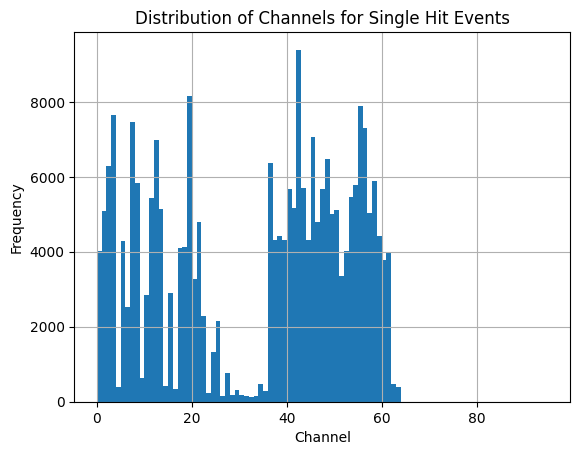

In [54]:
#most hitted channels
mask_here = single_hit_mask & valid_mask 
plt.hist(channel[mask_here][:, 0], bins=np.arange(0, 96, 1), alpha=1)
plt.xlabel('Channel')
plt.ylabel('Frequency')
plt.title('Distribution of Channels for Single Hit Events')
#plt.ylim(0, 7500)  # Imposta un limite massimo per l'asse y
plt.grid()
plt.show()

In [55]:
flat_channels = channel[mask_here][:, 0]
flat_channels

<Array [42, 42, 46, 46, 46, 9, ..., 36, 45, 21, 28, 1] type='242994 * int32'>

In [56]:
# funziona che mi ordina i canali piu colpiti indicandomi anche il numero di eventi con 1 hit

#flat_channels = ak.flatten(channel[single_hit_mask])
#channel_counts = np.bincount(flat_channels)
channel_counts = np.bincount(flat_channels)
sorted_indices = np.argsort(channel_counts)[::-1]
sorted_channels = np.arange(96)[sorted_indices]
sorted_counts = channel_counts[sorted_indices]

print("Canali più colpiti (ordinati):")
for ch, count in zip(sorted_channels, sorted_counts):
    print(f"Canale {ch}: {count} eventi")

Canali più colpiti (ordinati):
Canale 42: 9390 eventi
Canale 19: 8150 eventi
Canale 55: 7884 eventi
Canale 3: 7637 eventi
Canale 7: 7469 eventi
Canale 56: 7298 eventi
Canale 45: 7059 eventi
Canale 12: 6975 eventi
Canale 48: 6481 eventi
Canale 36: 6360 eventi
Canale 2: 6276 eventi
Canale 58: 5893 eventi
Canale 8: 5833 eventi
Canale 54: 5770 eventi
Canale 43: 5697 eventi
Canale 40: 5682 eventi
Canale 47: 5668 eventi
Canale 53: 5462 eventi
Canale 11: 5443 eventi
Canale 41: 5179 eventi
Canale 13: 5153 eventi
Canale 50: 5115 eventi
Canale 1: 5083 eventi
Canale 57: 5034 eventi
Canale 49: 5021 eventi
Canale 46: 4803 eventi
Canale 21: 4782 eventi
Canale 59: 4432 eventi
Canale 38: 4411 eventi
Canale 37: 4326 eventi
Canale 39: 4315 eventi
Canale 44: 4315 eventi
Canale 5: 4285 eventi
Canale 18: 4115 eventi
Canale 17: 4114 eventi
Canale 0: 4026 eventi
Canale 52: 4015 eventi
Canale 61: 3968 eventi
Canale 60: 3785 eventi
Canale 51: 3354 eventi
Canale 20: 3270 eventi
Canale 15: 2902 eventi
Canale 10:

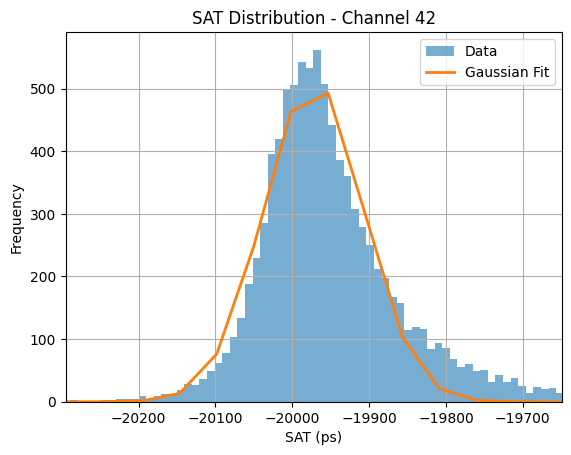

Channel 42: mu = -19972.14 ps, sigma = 64.53 ps


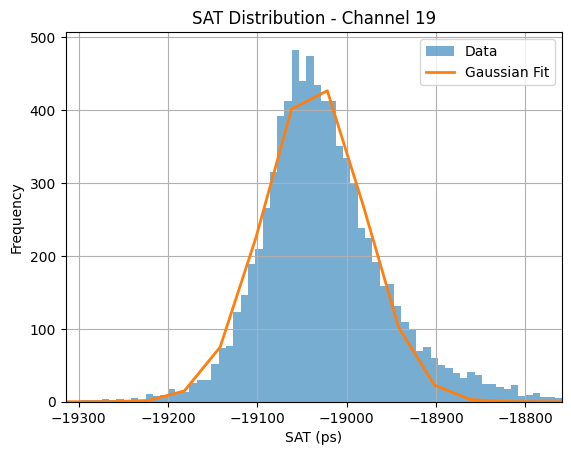

Channel 19: mu = -19037.05 ps, sigma = 55.53 ps


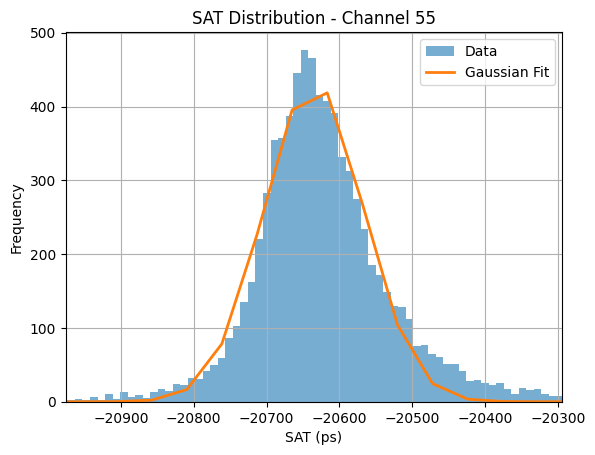

Channel 55: mu = -20635.41 ps, sigma = 68.05 ps


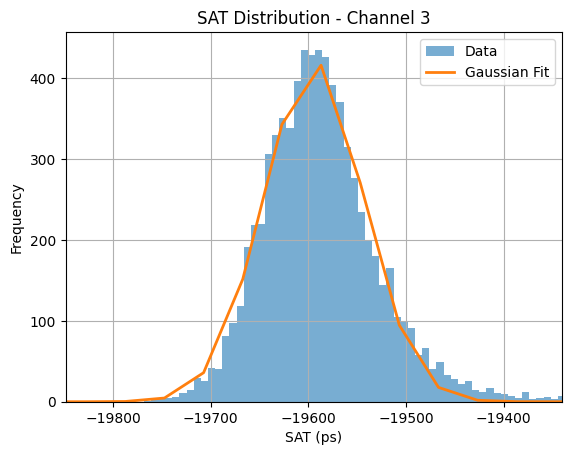

Channel 3: mu = -19594.53 ps, sigma = 50.82 ps


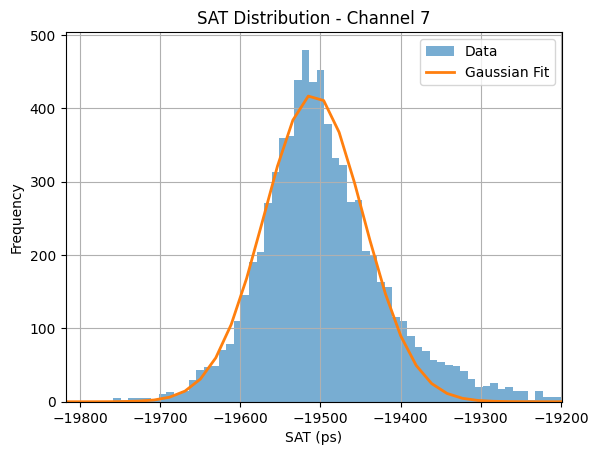

Channel 7: mu = -19508.54 ps, sigma = 61.89 ps


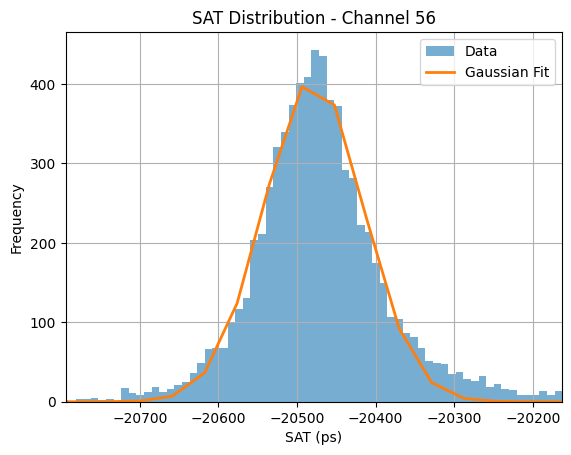

Channel 56: mu = -20478.78 ps, sigma = 63.09 ps


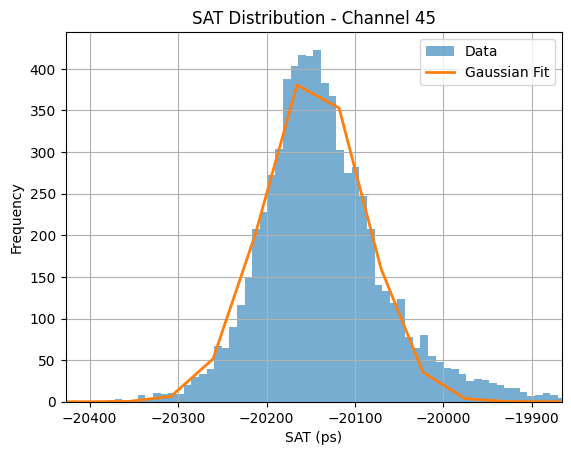

Channel 45: mu = -20146.74 ps, sigma = 56.08 ps


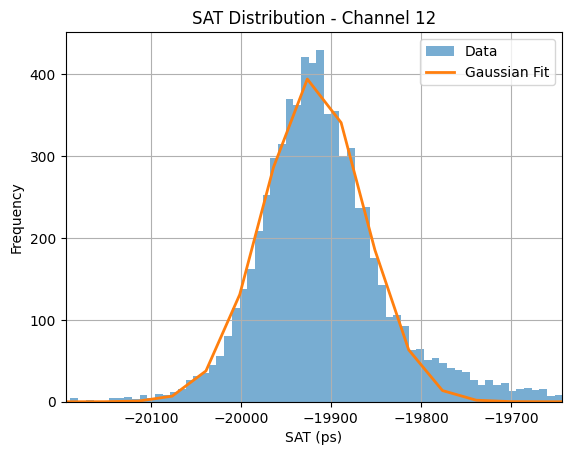

Channel 12: mu = -19919.16 ps, sigma = 55.09 ps


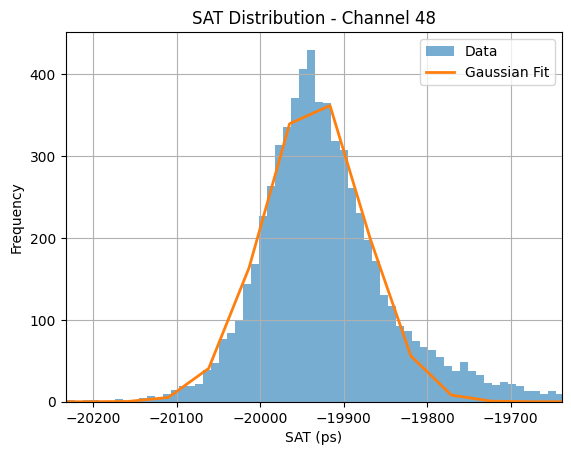

Channel 48: mu = -19936.00 ps, sigma = 59.39 ps


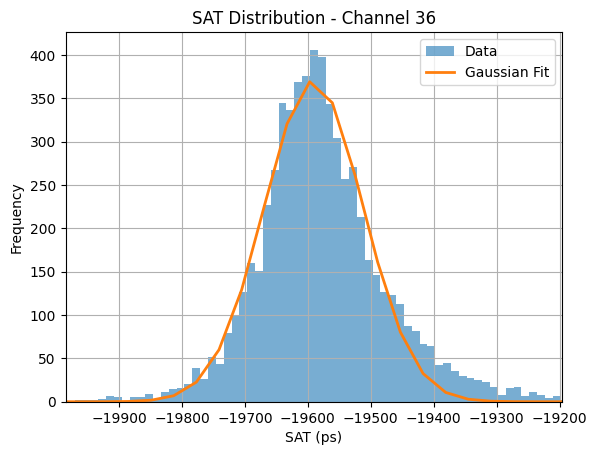

Channel 36: mu = -19590.76 ps, sigma = 78.82 ps


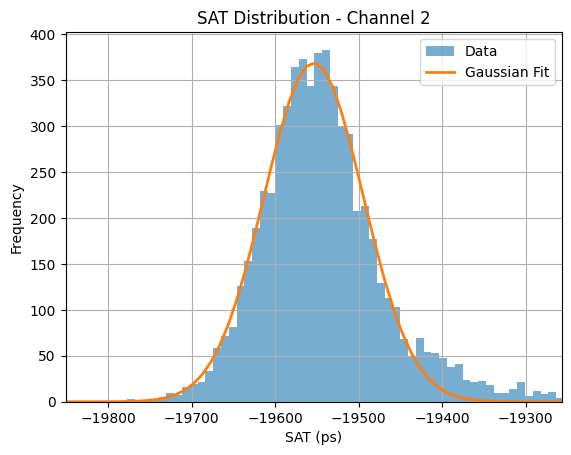

Channel 2: mu = -19553.83 ps, sigma = 59.43 ps


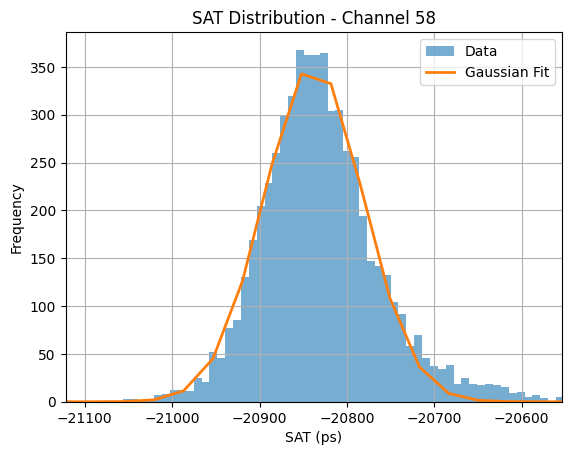

Channel 58: mu = -20838.04 ps, sigma = 56.76 ps


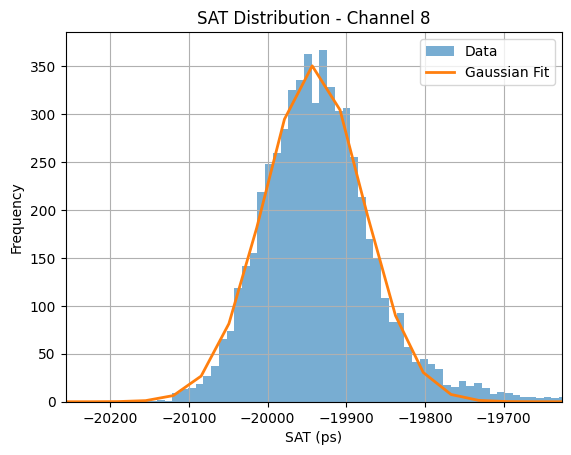

Channel 8: mu = -19941.51 ps, sigma = 63.02 ps


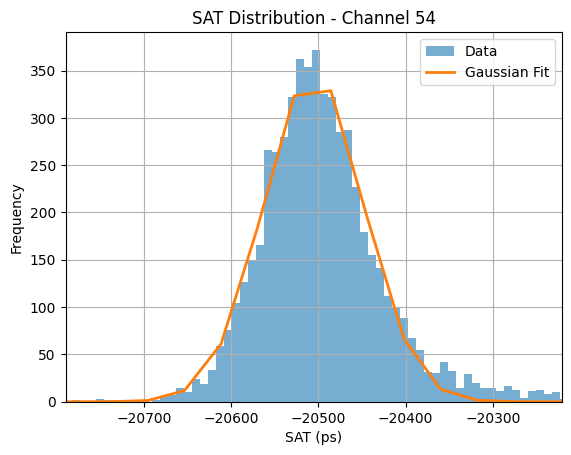

Channel 54: mu = -20505.51 ps, sigma = 56.91 ps


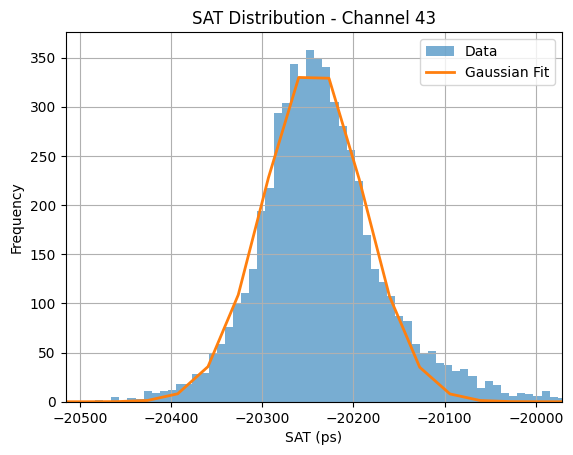

Channel 43: mu = -20243.68 ps, sigma = 54.38 ps


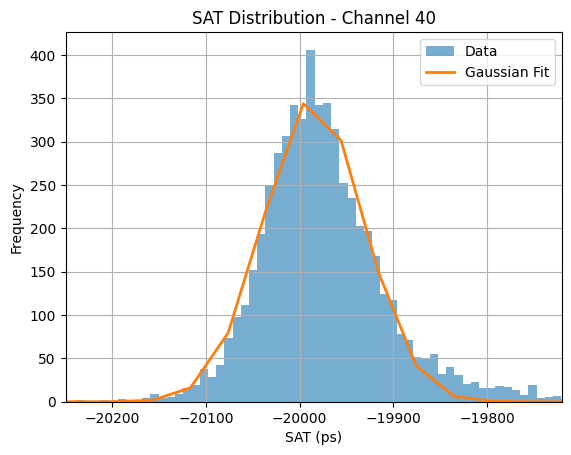

Channel 40: mu = -19985.06 ps, sigma = 52.89 ps


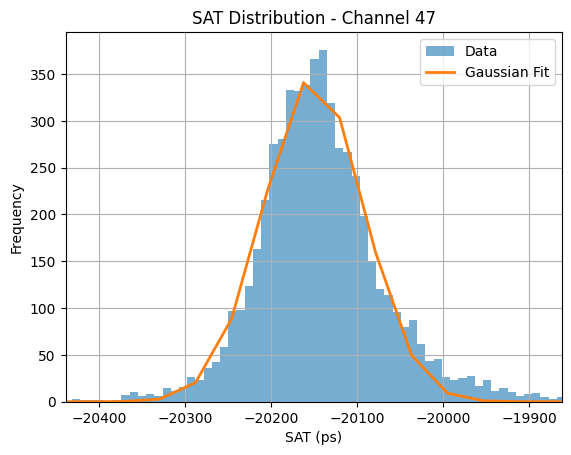

Channel 47: mu = -20150.76 ps, sigma = 57.71 ps


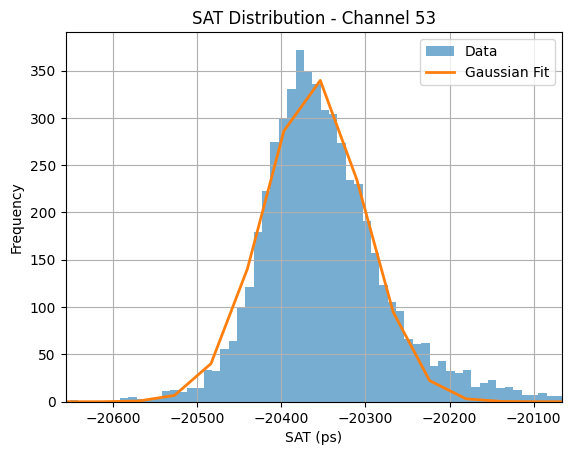

Channel 53: mu = -20361.54 ps, sigma = 58.94 ps


In [ ]:
##### analisi di tutti i canali con almeno 1000 eventi
sorted_sigmas = []
sorted_channels_ok= []
for x in sorted_channels:
    ##gaus analysis
    channel_mask = channel[:, 0] == x
    single_hit_mask = hits == 1
    valid_mask = (
        (ak.num(amplitude_PICOSEC) >= 1) &
        (ak.num(cfd_PICO) >= 1) 
    )
    event_mask = channel_mask & single_hit_mask & valid_mask
    good_amplitude = amplitude_PICOSEC[event_mask][:,0]
    good_SAT = cfd_PICO[event_mask][:,0] - cfd_MCP[event_mask] - (Cell0TimeStamp_MCP[event_mask]*1e3-Cell0TimeStamp_PICOSEC[event_mask][:,0]*1e3)   
    sat_values = ak.to_numpy(good_SAT)
    sat_values = sat_values[~np.isnan(sat_values)]
    if len(sat_values) < 1000:
        continue
    mean = np.mean(sat_values)
    std = np.std(sat_values)
    bins = 'fd'
    hist, bin_edges = np.histogram(sat_values, bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    popt, pcov = curve_fit(
    gauss,
    bin_centers,
    hist,
    p0=[max(hist), mean, std],
    bounds=([0, -np.inf, 0], [np.inf, np.inf, np.inf])
)
    A_fit, mu_fit, sigma_fit = popt
    x_fit = np.linspace(bin_edges[0], bin_edges[-1], 2000)
    y_fit = gauss(x_fit, *popt)
    plt.hist(sat_values, bins=bins, alpha=0.6, label='Data')
    plt.plot(x_fit, y_fit, linewidth=2, label='Gaussian Fit')
    plt.xlabel('SAT (ps)')
    plt.ylabel('Frequency')
    plt.title(f'SAT Distribution - Channel {x}')
    plt.xlim(mu_fit - 5*sigma_fit, mu_fit + 5*sigma_fit)
    plt.legend()
    plt.grid()
    plt.show()
    print(f"Channel {x}: mu = {mu_fit:.2f} ps, sigma = {sigma_fit:.2f} ps") 
    sorted_sigmas.append((x, sigma_fit))
    

